# ADT HAGI++ vs SparseGaze

Interactive comparison for HAGI++ sliding predictions and SparseGaze rollout variants on ADT. SparseGaze artifacts are stored as world gaze vectors, so this notebook converts them back to CPF with `T_world_CPF` before plotting pitch/yaw.

In [1]:
from pathlib import Path
import importlib
import sys

cwd = Path.cwd()
repo_root = cwd if (cwd / 'visualization').exists() else cwd.parent
sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import pandas as pd
import visualization.adt_hagi_sparsegaze_compare as compare

compare = importlib.reload(compare)
DEFAULT_HAGI_DIR = compare.DEFAULT_HAGI_DIR
DEFAULT_SPARSEGAZE_DIR = compare.DEFAULT_SPARSEGAZE_DIR
available_frame_rates = compare.available_frame_rates
comparison_metrics = compare.comparison_metrics
make_widget = compare.make_widget
plot_sequence = compare.plot_sequence
reported_summary = compare.reported_summary
sequence_summary = compare.sequence_summary
sequence_names = compare.sequence_names

plt.style.use('default')
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_rows', 100)

print('HAGI++:', DEFAULT_HAGI_DIR)
print('SparseGaze:', DEFAULT_SPARSEGAZE_DIR)
print('common FPS:', available_frame_rates())

HAGI++: /home/liumu/Github_Projects/HAGI/save/head/hagi++_imputation/adt_low_framerate_sliding
SparseGaze: /home/liumu/Github_Projects/SparseGaze/outputs/eval/adt/sparsegaze_cpf_forward_head_motion_residual_ss
common FPS: [15, 10, 6]


## Reported Summary

This table reads the saved summary files. HAGI++ and SparseGaze may use slightly different evaluated frame sets here; use the next table for common-frame MAE.

In [2]:
reported_summary()

,method,fps,n,mae_deg,p90_deg,velocity_js
1,HAGI++,15,12960,1.518015,4.475766,0.044699
13,SparseGaze gt-repair,15,13635,1.400697,4.164043,0.045717
7,SparseGaze linear,15,13635,1.431957,4.293984,0.045786
10,SparseGaze pchip,15,13635,1.426259,4.246555,0.042851
4,SparseGaze rollout,15,13635,1.425458,4.190563,0.037530
0,HAGI++,10,17275,2.155667,6.230831,0.084296
14,SparseGaze gt-repair,10,18174,1.930867,5.739021,0.051704
8,SparseGaze linear,10,18174,1.996473,5.903744,0.054256
11,SparseGaze pchip,10,18174,1.994285,5.888254,0.049344
5,SparseGaze rollout,10,18174,2.007382,5.827215,0.038612


## Common-frame MAE

This recomputes angular error on frames that are present in HAGI++ sliding output and marked as missing/evaluated in SparseGaze.

In [3]:
pd.concat([comparison_metrics(fps).assign(fps=fps) for fps in available_frame_rates()], ignore_index=True)

,method,n_common,mae_deg,median_deg,p90_deg,fps
0,HAGI++,12960,1.518015,0.558481,4.475766,15
1,SparseGaze rollout,12960,1.417909,0.509333,4.164713,15
2,SparseGaze linear,12960,1.425036,0.505194,4.244688,15
3,SparseGaze pchip,12960,1.419193,0.506129,4.201326,15
4,SparseGaze gt-repair,12960,1.393273,0.494368,4.117513,15
5,HAGI++,17275,2.155667,0.816373,6.230832,10
6,SparseGaze rollout,17275,2.003707,0.722506,5.816230,10
7,SparseGaze linear,17275,1.994907,0.678540,5.901549,10
8,SparseGaze pchip,17275,1.992264,0.687045,5.885734,10
9,SparseGaze gt-repair,17275,1.928777,0.659072,5.736529,10


## Interactive Sequence View

Use the method checkboxes to compare any subset of HAGI++ and SparseGaze variants. Uncheck HAGI++ to inspect only SparseGaze rollout variants.

The widget shows a whole-sequence summary table above the plot. MAE/median/p90 are recomputed for the selected sequence; velocity JS is read from the saved FPS-level summary JSON because the current artifacts do not contain per-sequence JS.

Anchor GT is shown as blue points. Missing GT and predictions are connected only within each anchor interval, and the line is broken at anchors. The bottom panel overlays per-frame angular error for direct method comparison.

In [4]:
make_widget()

Output()

(VBox(children=(HBox(children=(Dropdown(description='FPS', index=2, options=(15, 10, 6), value=6), Dropdown(description='Sequence', options=('Apartment_release_decoration_skeleton_seq133_M1292', 'Apartment_release_decoration_skeleton_seq134_M1292', 'Apartment_release_decoration_skeleton_seq139_M1292', 'Apartment_release_meal_skeleton_seq131_M1292', 'Apartment_release_meal_skeleton_seq132_M1292', 'Apartment_release_meal_skeleton_seq135_M1292', 'Apartment_release_work_skeleton_seq107_M1292', 'Apartment_release_work_skeleton_seq132_M1292', 'Apartment_release_work_skeleton_seq135_M1292', 'Apartment_release_work_skeleton_seq138_M1292'), value='Apartment_release_decoration_skeleton_seq133_M1292'))), HBox(children=(BoundedIntText(value=149, description='Start', layout=Layout(width='180px'), max=2734), BoundedIntText(value=240, description='Length', layout=Layout(width='180px'), max=2735, min=1), Checkbox(value=True, description='Anchors'), Checkbox(value=True, description='Missing GT'))), VBo

## Static Example

Use this if ipywidgets is unavailable.

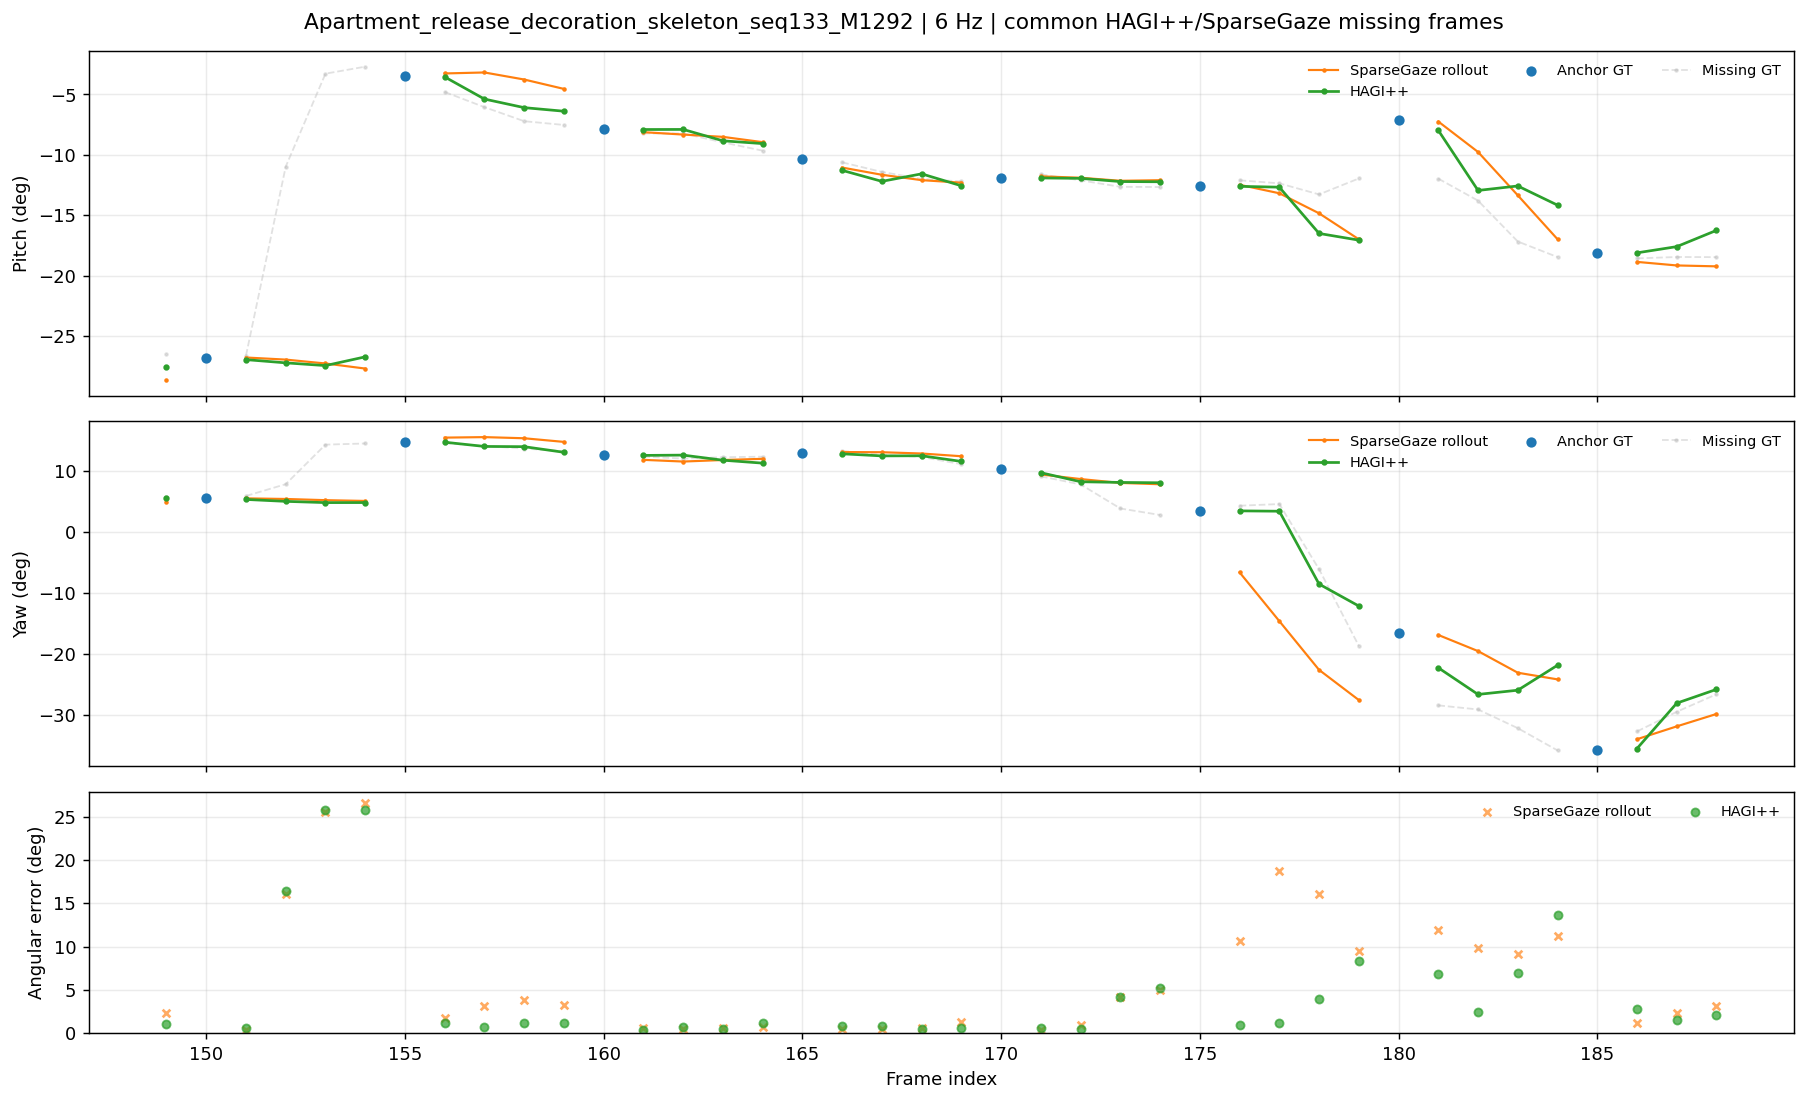

In [5]:
seq = sequence_names(fps=6)[0]
plot_sequence(fps=6, sequence_name=seq, start_frame=149, length=40);